# Imports

In [180]:
import pandas as pd

import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             mean_absolute_error, mean_squared_error, r2_score)
import plotly.express as px
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 10

In [204]:
df = pd.read_csv('C:/Users/Usuario/Proyectos/Datos/Breast Cancer Data.csv')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [182]:
display(df.info())
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

None

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# Funciones

In [183]:
def display_unique_counts(df_data):
    """
    Muestra la cantidad de valores únicos y los valores mismos (si no son demasiados)
    para cada columna en un DataFrame.

    Args:
        df_data (pd.DataFrame): El DataFrame a analizar.
    """
    MAX_UNIQUE_DISPLAY = 50  # Define el número máximo de valores únicos a mostrar

    print("\nValores únicos por columna:")
    for col in df_data.columns:
        unique_count = df_data[col].nunique()
        print("\n")
        print(f"Columna '{col}': {unique_count} valores únicos")
        if unique_count <= MAX_UNIQUE_DISPLAY:
            unique_values = df_data[col].unique()
            print(f"  Valores: {unique_values}")
        else:
            print(f"  (Demasiados valores únicos para mostrar, mostrando solo el conteo de {unique_count})")

In [184]:
def separate_columns_by_type(df):
    """
    Separa las columnas de un DataFrame en listas de columnas numéricas y categóricas/discretas.
    Considera una columna numérica como discreta si tiene un tipo entero y un número limitado de valores únicos.

    Args:
        df (pd.DataFrame): El DataFrame a analizar.

    Returns:
        tuple: Un par de listas (categorical_cols, numerical_cols).
    """
    categorical_cols = []
    numerical_cols = []

    for col in df.columns:
        # Excluir la columna 'type' si es de tipo object/category y ya se sabe que es categórica
        if col == 'type':
            categorical_cols.append(col)
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            # Heurística para columnas numéricas discretas (enteros con pocos valores únicos)
            if pd.api.types.is_integer_dtype(df[col]) and df[col].nunique() < 20:
                # Si es un entero y tiene menos de 20 valores únicos, podría ser discreta/categórica
                # 'quality' es un buen ejemplo aquí
                categorical_cols.append(col)
            else:
                numerical_cols.append(col)
        else:
            # Todo lo demás (object, category) es tratado como categórico
            categorical_cols.append(col)

    return categorical_cols, numerical_cols

In [185]:
def plot_numerical_distributions(df_data, column_names):
    """
    Genera histogramas con estimación de densidad de kernel (KDE) para múltiples columnas numéricas.
    La función ajusta automáticamente el diseño de la cuadrícula de los gráficos.

    Args:
        df_data (pd.DataFrame): El DataFrame que contiene los datos.
        column_names (list): Una lista de cadenas con los nombres de las columnas a graficar.
    """
    num_plots = len(column_names)

    if num_plots == 0:
        print("No se proporcionaron columnas para graficar.")
        return

    if num_plots == 1:
        nrows, ncols = 1, 1
    elif num_plots == 2:
        nrows, ncols = 1, 2
    else: # For 3 or more plots, aim for 2 columns per row
        nrows = (num_plots + 1) // 2
        ncols = 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    fig.suptitle('Distribución de Características Numéricas', fontsize=16)

    # Aplanar los ejes para facilitar la iteración si hay múltiples filas/columnas
    if num_plots == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    for i, col in enumerate(column_names):
        if i < len(axes_flat):
            sns.histplot(df_data[col], kde=True, ax=axes_flat[i], color='teal')
            axes_flat[i].set_title(f'Distribución de {col}')
            axes_flat[i].set_xlabel(col)
            axes_flat[i].set_ylabel('Frecuencia')

    # Ocultar ejes vacíos si los hay
    for j in range(num_plots, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [186]:
def plot_numerical_distributions_all(df_data):
    """
    Genera histogramas con estimación de densidad de kernel (KDE) para múltiples columnas numéricas.
    La función ajusta automáticamente el diseño de la cuadrícula de los gráficos.

    Args:
        df_data (pd.DataFrame): El DataFrame que contiene los datos.
    """
    # Obtener las columnas numéricas internamente
    _, numerical_cols_to_plot = separate_columns_by_type(df_data)

    num_plots = len(numerical_cols_to_plot)

    if num_plots == 0:
        print("No se encontraron columnas numéricas para graficar.")
        return

    if num_plots == 1:
        nrows, ncols = 1, 1
    elif num_plots == 2:
        nrows, ncols = 1, 2
    else:
        nrows = (num_plots + 1) // 2
        ncols = 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    fig.suptitle('Distribución de Características Numéricas', fontsize=16)

    if num_plots == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    for i, col in enumerate(numerical_cols_to_plot):
        if i < len(axes_flat):
            sns.histplot(df_data[col], kde=True, ax=axes_flat[i], color='teal')
            axes_flat[i].set_title(f'Distribución de {col}')
            axes_flat[i].set_xlabel(col)
            axes_flat[i].set_ylabel('Frecuencia')

    for j in range(num_plots, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# EDA

No se encontraron datos nulos (A excepción de la feature "Unnamed" la cual se considerará error). 

Se eliminan las features "Id" y "Unnamed" ya que no son necesarias.

In [187]:
df_limpio1 = df.copy()

df_limpio1.drop(columns=['id', 'Unnamed: 32'], inplace=True)

Separar las variables según si son numéricas o categóricas

In [188]:
categorical_cols, numerical_cols = separate_columns_by_type(df_limpio1)
numerical_cols

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

Matriz de correlación

In [189]:
df_limpio1['diagnosis'].value_counts(dropna=False)

diagnosis
B    357
M    212
Name: count, dtype: int64

[1 0]


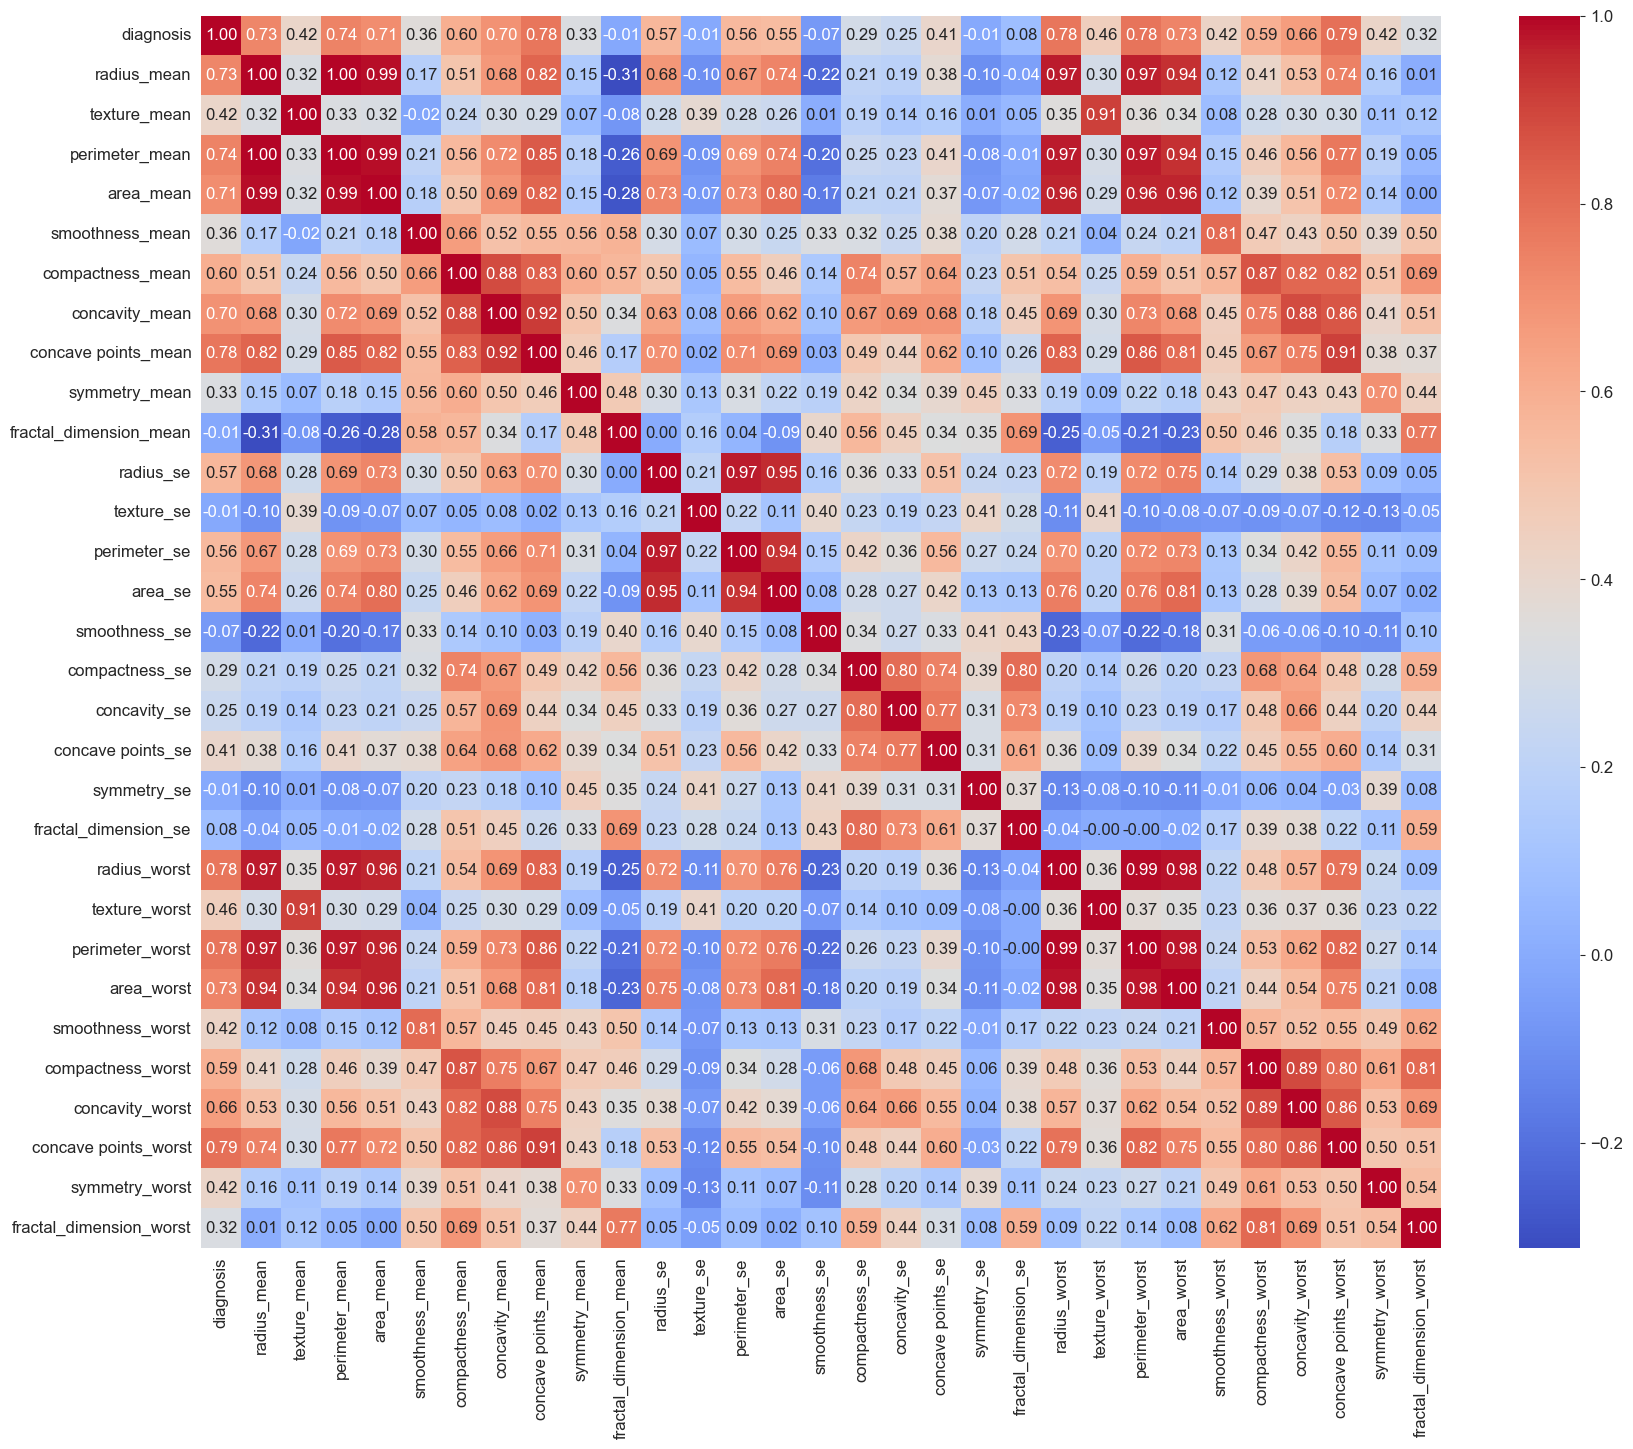

In [190]:
df_limpio1['diagnosis'] = df_limpio1['diagnosis'].apply(lambda x: 1 if x == 'M' else 0)
print(df_limpio1['diagnosis'].unique())

plt.figure(figsize=(20, 16))
sns.heatmap(df_limpio1.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()



Las variables 'fractal_dimension_mean' y 'texture_se' tienen una correlación casi nula con nuestra variable target, por lo tanto serán excluidas.

In [191]:
df_limpio1.drop(columns=['fractal_dimension_mean', 'texture_se'], inplace=True)

In [192]:
df_final = df_limpio1.copy()


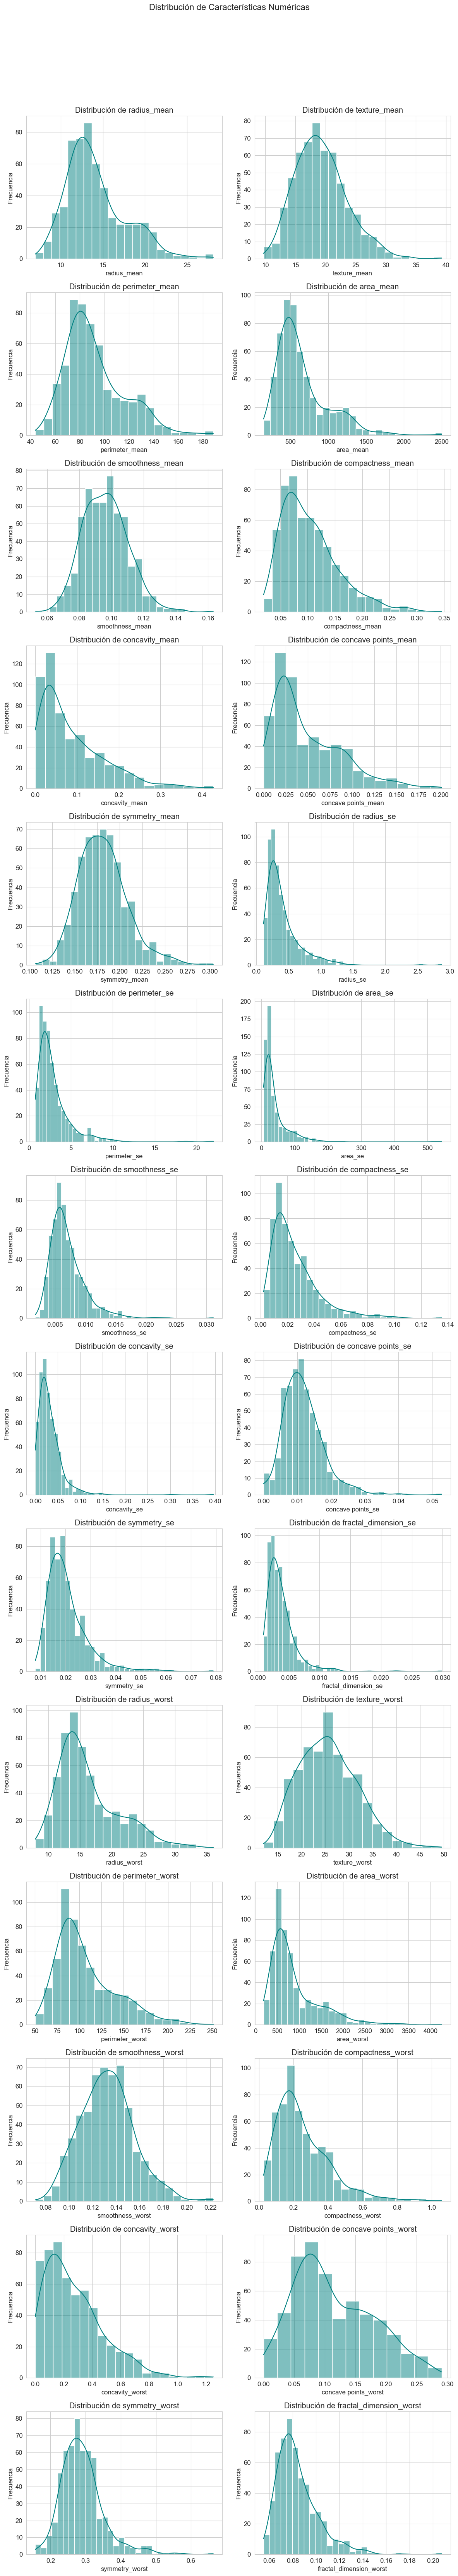

In [193]:
plot_numerical_distributions_all(df_final)

# Preparación de datos

In [194]:
x = df_final.drop('diagnosis', axis=1)
y = df_final['diagnosis']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Entrenamiento del modelo : Regresión logística

Se utilizará un modelo de regresión logística para intentar predecir el diagnóstico de cancer de mama con los datos otorgados. 

Se utiliza RobustScaler para escalar los datos, teniendo en cuenta que no se realizó ningún filtro de outliers por tratarse de datos médicos donde puede existir gran variabilidad entre personas.

In [195]:
from sklearn.preprocessing import RobustScaler

modelo = LogisticRegression(max_iter=1000)

scaler = RobustScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_train.columns)

modelo.fit(x_train_scaled, y_train)

y_pred = modelo.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       108
           1       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



# Evaluación del modelo

Se procede a evaluar el modelo, para deshacernos de sospechas de overfitting, teniendo en cuenta los altos valores de accuracy y recall.

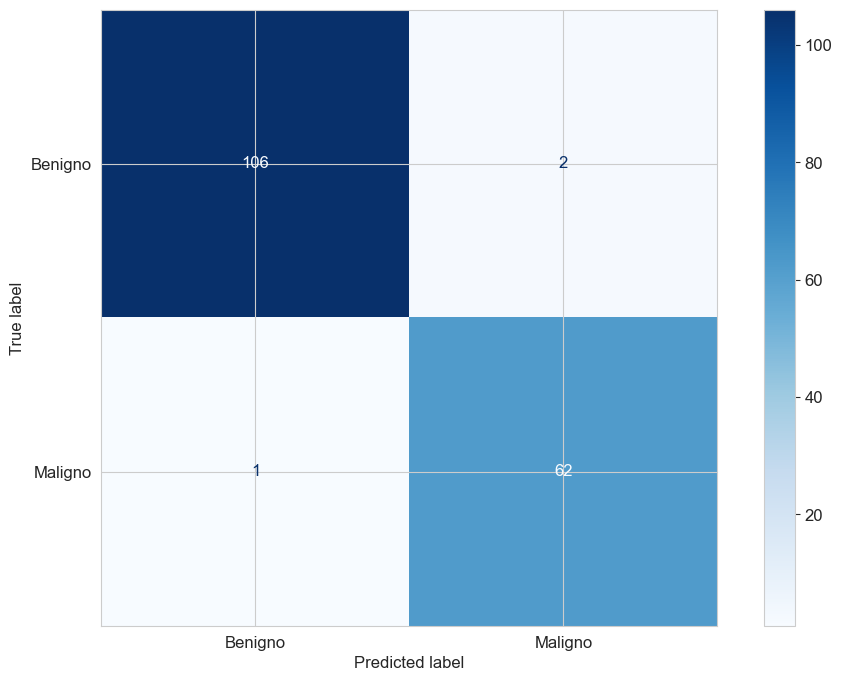

In [196]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues')
plt.show()

In [197]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, x_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.3f} (+/- {scores.std():.3f})")

Accuracy promedio: 0.975 (+/- 0.016)


El modelo se ve muy solido, con una alta accuracy.

Para continuar probandolo, procedo a crear datos sintéticos basados en el dataframe original, con los cuales probaré el modelo una vez más.

In [198]:
datos_sinteticos = []
for clase in [0, 1]:
    subset = df_final[df_final['diagnosis'] == clase].drop(columns='diagnosis')
    media = subset.mean()
    cov = subset.cov()
    sinteticos = np.random.multivariate_normal(media, cov, size=200)
    df_sint = pd.DataFrame(sinteticos, columns=subset.columns)
    df_sint['diagnosis'] = clase
    datos_sinteticos.append(df_sint)

df_sintetico = pd.concat(datos_sinteticos, ignore_index=True)
print(df_sintetico.shape)
df_sintetico.head()

(400, 29)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,13.699189,16.803666,88.262549,591.200492,0.100423,0.097906,0.068232,0.037328,0.184555,0.314759,...,20.301202,97.411411,705.561860,0.121972,0.254014,0.304083,0.117437,0.306569,0.071702,0
1,11.576209,19.689974,75.229243,436.300987,0.093554,0.121146,0.114564,0.039738,0.180912,0.309522,...,22.483342,87.016902,571.082992,0.126503,0.296647,0.351090,0.105603,0.269166,0.097781,0
2,10.674237,19.416045,68.880349,347.645385,0.090713,0.090064,0.050029,0.018073,0.216881,0.191501,...,25.834566,77.395742,419.887431,0.119364,0.232140,0.244687,0.076643,0.341985,0.094274,0
3,12.194384,21.200561,77.582679,459.353247,0.063784,0.039451,-0.007502,-0.009157,0.116356,0.045877,...,26.509965,82.675703,491.615598,0.100428,0.136676,0.097652,0.027883,0.212841,0.071473,0
4,16.103259,19.530140,104.194531,769.603991,0.091248,0.075418,0.024049,0.026887,0.130288,0.230060,...,29.148329,118.049964,919.858525,0.129302,0.205073,0.141272,0.109563,0.261639,0.071607,0


In [199]:
x_sint = df_sintetico.drop(columns='diagnosis')
y_sint = df_sintetico['diagnosis']

scaler_sint = RobustScaler()
x_sint_scaled = pd.DataFrame(scaler_sint.fit_transform(x_sint), columns=x_sint.columns)

y_pred_sint = modelo.predict(x_sint_scaled)
print(classification_report(y_sint, y_pred_sint))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       200
           1       1.00      0.80      0.89       200

    accuracy                           0.90       400
   macro avg       0.92      0.90      0.90       400
weighted avg       0.92      0.90      0.90       400



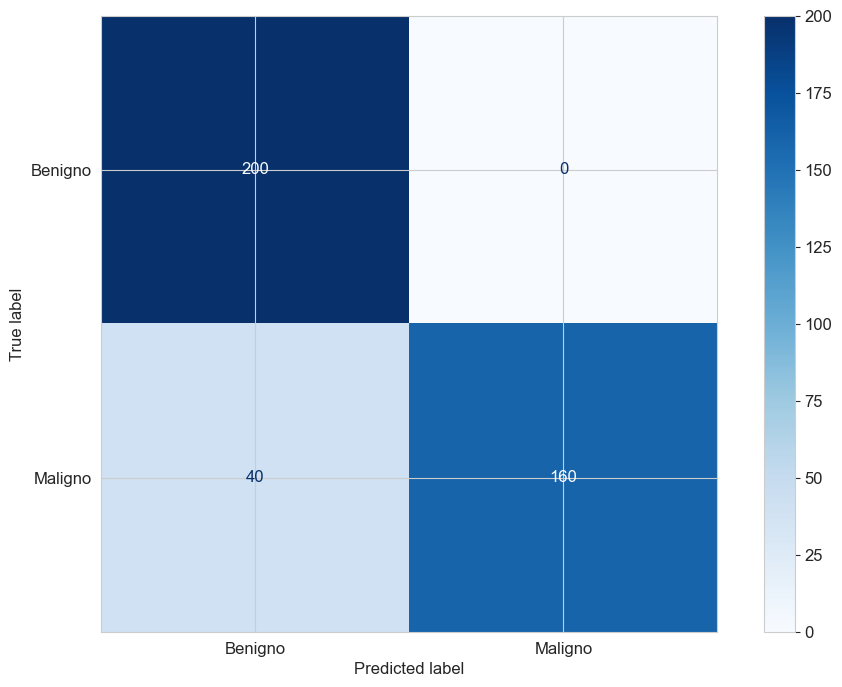

In [200]:
cm = confusion_matrix(y_sint, y_pred_sint)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues')
plt.show()

El modelo sigue manteniendo un accuracy muy alto. Se puede decir que se mantiene sólido al resultar tan efectivo
con datos distintos a los originales. Debido al valor de Falsos Negativos observados, se probará
reduciendo el umbral de decisión, ya que se trata de un caso médico en donde es preferible tener 
más Falsos Positivos que falsos Negativos.

Se tiene en cuenta también, que los datos sintéticos no son la mejor representación de valores reales que podría haber en estos casos.

In [201]:
y_prob = modelo.predict_proba(x_sint_scaled)[:, 1]
y_pred_umbral = (y_prob >= 0.2).astype(int)
print(classification_report(y_sint, y_pred_umbral))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       200
           1       0.99      0.88      0.93       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.93       400
weighted avg       0.94      0.94      0.93       400



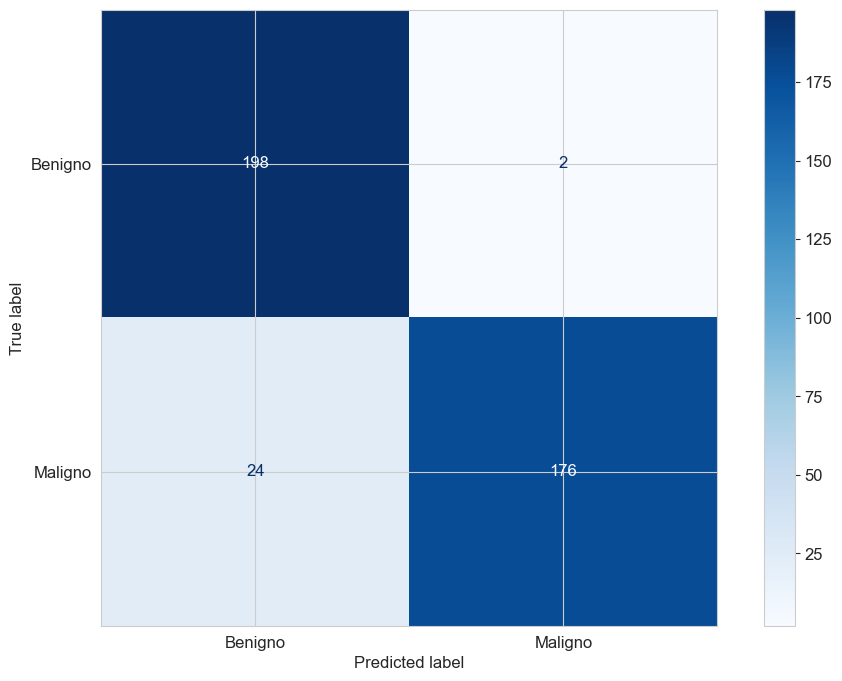

In [202]:
cm = confusion_matrix(y_sint, y_pred_umbral)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
disp.plot(cmap='Blues')
plt.show()

# Conclusión

Se logró un modelo de regresión logística con una accuracy de 0.97 en los datos originales
y accuracy de entre 0.90 y 0.93 al utilizarlo con datos sintéticos basados en el dataframe inicial.

El modelo se muestra bastante sólido, siendo preferible utilizar un umbral de detección más bajo 
debido a la naturaleza del caso trabajado.